In [19]:
import sys
sys.path.insert(0, '../..')
import math
import numpy as np
import matplotlib.pyplot as plt 
import mssfp
import deepssfp
from deepssfp import dataloader, view, recon, dataformatter, deepssfp, models, plotlib

In [8]:
dataset = mssfp.generate_ssfp_dataset(N=128, npcs=8, f=500, alpha=np.deg2rad(60), sigma=0.0001, data_indices=[(None, None), (120,180)], rotate=True, deform=True)
data = dataset['M']
fieldmap = dataset['phantom']['offres']
T1 = dataset['phantom']['t1_map']
T2 = dataset['phantom']['t2_map']
data.shape

Generating 3d phantom:(1200, 434, 362)


100%|██████████| 1200/1200 [00:22<00:00, 53.91it/s]


(1200, 128, 128, 8)

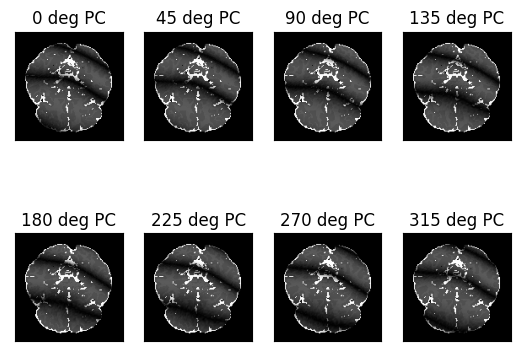

In [9]:
mssfp.plot_dataset(data, slice=0)

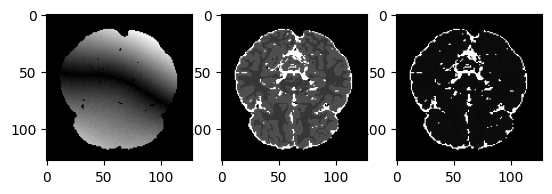

In [10]:
plt.figure()
plt.subplot(1,3,1)
plt.imshow(np.abs(fieldmap[0,:,:]))
plt.subplot(1,3,2)
plt.imshow(np.abs(T1[0,:,:]))
plt.subplot(1,3,3)
plt.imshow(np.abs(T2[0,:,:]))
plt.show()

In [11]:
mode = 'SyntheticBanding'
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)

X: (1200, 128, 128, 8)
X: (1200, 128, 128, 8) Y: (1200, 128, 128, 8)
(960, 128, 128, 8) (960, 128, 128, 8)


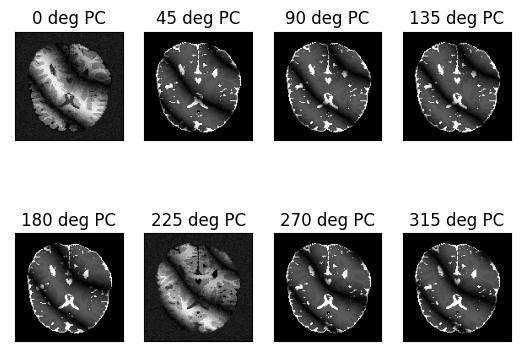

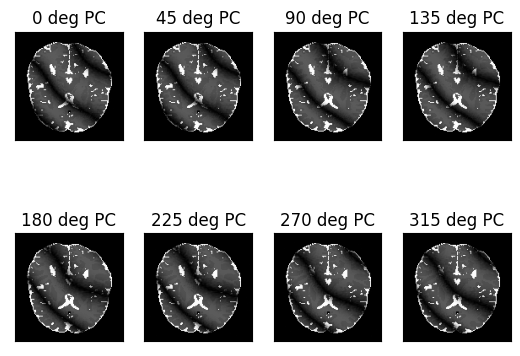

In [12]:
mssfp.plot_dataset(ds.x_train, slice=200)
mssfp.plot_dataset(ds.y_train, slice=200)

In [13]:
mode = 'SyntheticBanding'
model, history, ds, predictions = deepssfp.train(mode, epochs=400, input_data=data)

X: (1200, 128, 128, 8)
X: (1200, 128, 128, 8) Y: (1200, 128, 128, 8)
Training DataSet: (960, 128, 128, 8) (960, 128, 128, 8)
Test DataSet: (240, 128, 128, 8) (240, 128, 128, 8)
DL Model: 128, 128, 8, 8
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 8) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 2336        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________

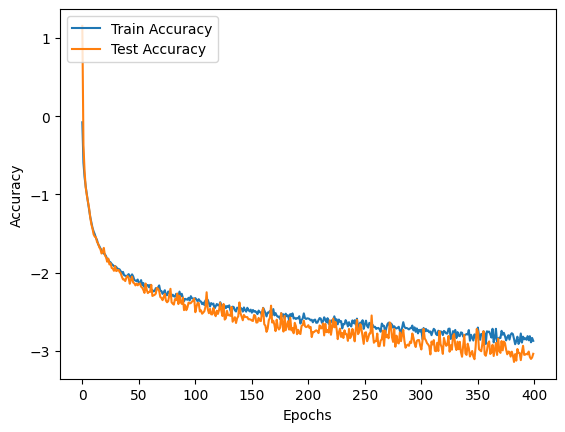

In [14]:
plotlib.plot_model_history(history)

In [15]:
ds.x_test.shape, ds.y_test.shape, predictions.shape

((240, 128, 128, 8), (240, 128, 128, 8), (240, 128, 128, 8))

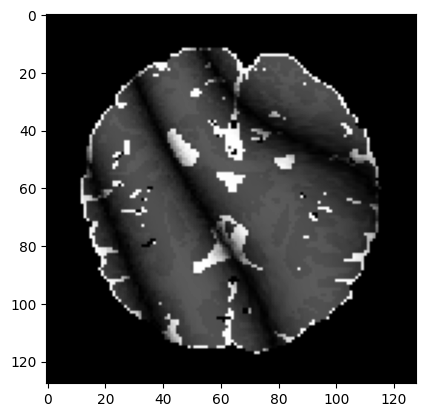

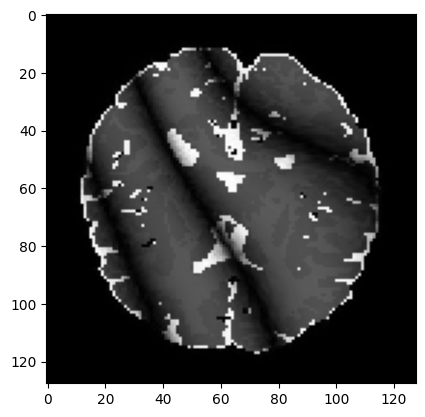

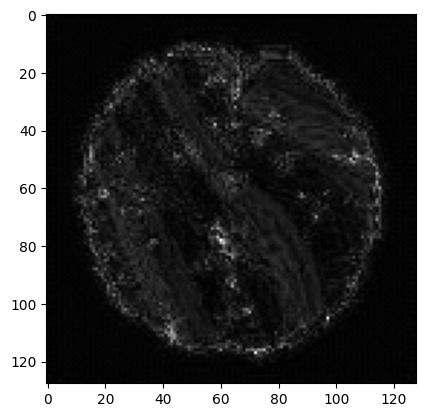

In [35]:
slice = 0
ii = 0
y0 = ds.y_test[slice,:,:,ii] + 1j * ds.y_test[slice,:,:,ii+1]
plt.imshow(np.abs(y0))
plt.show()

p0 = predictions[slice,:,:,ii] + 1j * predictions[slice,:,:,ii+1]
plt.imshow(np.abs( p0 ))
plt.show()

diff = np.abs(y0 - p0)
plt.imshow(diff)
plt.show()

In [27]:
def complex_to_real_img(data):
    ''' Combines real and imaginary channels into complex data '''
    s = data.shape
    out = np.zeros((s[0], s[1], s[2], math.floor(s[3] / 2)))
    for ii in range(math.floor(s[3] / 2)):
        out[:,:,:,ii] = data[:,:,:,2*ii] + 1j * data[:,:,:,2*ii+1]
    return out

C:\Users\mmend\AppData\Local\Temp\ipykernel_33608\588795027.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  out[:,:,:,ii] = data[:,:,:,2*ii] + 1j * data[:,:,:,2*ii+1]


(240, 128, 128, 4) (240, 128, 128, 4) (240, 128, 128, 4)
0
1
2
3


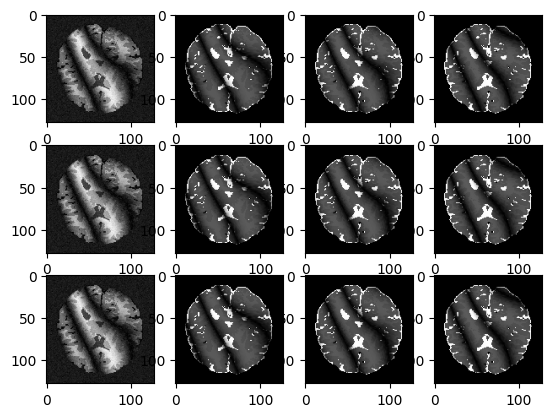

In [33]:
X = complex_to_real_img(ds.x_test)
Y = complex_to_real_img(ds.y_test)
Y_pred = complex_to_real_img(predictions)
print(X.shape, Y.shape, Y_pred.shape)

plt.figure()
slice = 0
for ii in range(X.shape[3]):
    print(ii)
    plt.subplot(3, X.shape[3], ii+1)
    plt.imshow(np.abs(X[slice,:,:,ii]))
    plt.subplot(3, Y.shape[3], ii+1 + X.shape[3])
    plt.imshow(np.abs(X[slice,:,:,ii]))
    plt.subplot(3, Y_pred.shape[3], ii+1 + X.shape[3] + Y.shape[3])
    plt.imshow(np.abs(X[slice,:,:,ii]))


Generating 3d phantom:(1, 434, 362)


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:64: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:91: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)
100%|██████████| 1/1 [00:00<00:00, 47.62it/s]


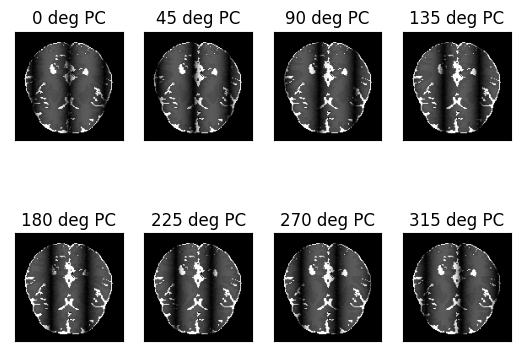

(1, 128, 128, 8)

In [54]:
TR: float = 3e-3
TE: float = 3e-3 / 2
alpha = np.deg2rad(60)
dataset_val = mssfp.generate_ssfp_dataset(N=128, npcs=8, f=500, alpha=alpha, sigma=0, data_indices=[1, 150])
M = dataset_val['M']
fieldmap = dataset_val['phantom']['offres']
T1 = dataset_val['phantom']['t1_map']
T2 = dataset_val['phantom']['t2_map']
mssfp.plot_dataset(M)
M.shape

In [55]:
x_val, y_val = ds.load_data(M)
print(f'X: {x_val.shape} Y: {y_val.shape}')



X: (1, 128, 128, 8)
X: (1, 128, 128, 8) Y: (1, 128, 128, 8)
X: (1, 128, 128, 8) Y: (1, 128, 128, 8)


In [52]:
ds.__dict__.keys()

dict_keys(['mode', 'x', 'y', 'SIZE', 'HEIGHT', 'WIDTH', 'CHANNELS_IN', 'CHANNELS_OUT', 'ratio', 'input', 'output', 'x_train', 'y_train', 'x_test', 'y_test'])

(128, 128, 1) (128, 128, 1) (128, 128, 1) (128, 128) (128, 128) (128, 128, 1)


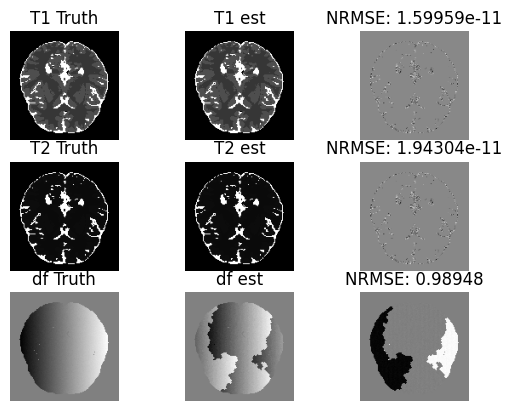

In [45]:
T1 =  np.squeeze(data['phantom']['t1_map'])
T2 =  np.squeeze(data['phantom']['t2_map'])
df =  np.squeeze(data['phantom']['offres'])

M =  np.squeeze(data['M'])
M = np.transpose(M, (2,0,1))
M = M[...,None]

M0 =  np.squeeze(data['phantom']['M0'])
mask = np.abs(M0) > 1e-8
mask = mask[...,None]

# Do the thing
Mmap, T1est, T2est, dfest = mssfp.planet(M, alpha, TR, mask=mask, pc_axis=0)

# Look at a single slice

print(T1est.shape, T2est.shape, dfest.shape, T1.shape, T2.shape, mask.shape)
sl = 0
T1est = T1est[..., sl]
T2est = T2est[..., sl]
dfest = dfest[..., sl]
mask = mask[..., sl]

# Simple phase unwrapping of off-resonance estimate.
from skimage.restoration import unwrap_phase
dfest = unwrap_phase(dfest*2*np.pi*TR)/(2*np.pi*TR)
mssfp.plot_planet_results(mask, T1, T1est, T2, T2est, df, dfest)